In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math
import shutil
import glob
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/Brain Tumor DataSet/Brain Tumor Data Set.zip'
metadata_path = '/content/drive/MyDrive/Brain Tumor DataSet/metadata.xls'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done!")

Done!


In [ ]:
df = pd.read_csv(metadata_path)
df.head()

,Unnamed: 0,image,class,format,mode,shape
0,0,Cancer (1).jpg,tumor,JPEG,RGB,"(512, 512, 3)"
1,1,Cancer (1).png,tumor,PNG,L,"(300, 240)"
2,2,Cancer (1).tif,tumor,TIFF,RGB,"(256, 256, 3)"
3,3,Cancer (10).jpg,tumor,JPEG,RGB,"(512, 512, 3)"
4,4,Cancer (10).tif,tumor,TIFF,RGB,"(256, 256, 3)"


In [ ]:
print("Total images :", len(os.listdir(extract_path)))
#number of images but its 1 because they are in a folder ie one level deeper
print(df['class'].value_counts())

Total images : 1
class
tumor     2513
normal    2087
Name: count, dtype: int64


In [ ]:
df.shape

(4600, 6)

In [ ]:
print(os.listdir(extract_path)[:10]) #this will tell the exact folder structure after unzipping
# to check is any sub folder being created or not

['Brain Tumor Data Set']


In [ ]:
# sub folder is being creaded we will go deep
inner_path = os.path.join(extract_path, 'Brain Tumor Data Set')
print(os.listdir(inner_path)[:10])
print("Total:", len(os.listdir(inner_path)))

['Healthy', 'Brain Tumor']
Total: 2


In [ ]:
healthy_path = '/content/dataset/Brain Tumor Data Set/Healthy'
tumor_path = '/content/dataset/Brain Tumor Data Set/Brain Tumor'

# Count images in each folder
healthy_images = os.listdir(healthy_path)
tumor_images = os.listdir(tumor_path)
print("Healthy images:", len(healthy_images))
print("Tumor images:", len(tumor_images))
print("Total:", len(healthy_images) + len(tumor_images))

Healthy images: 2087
Tumor images: 2513
Total: 4600


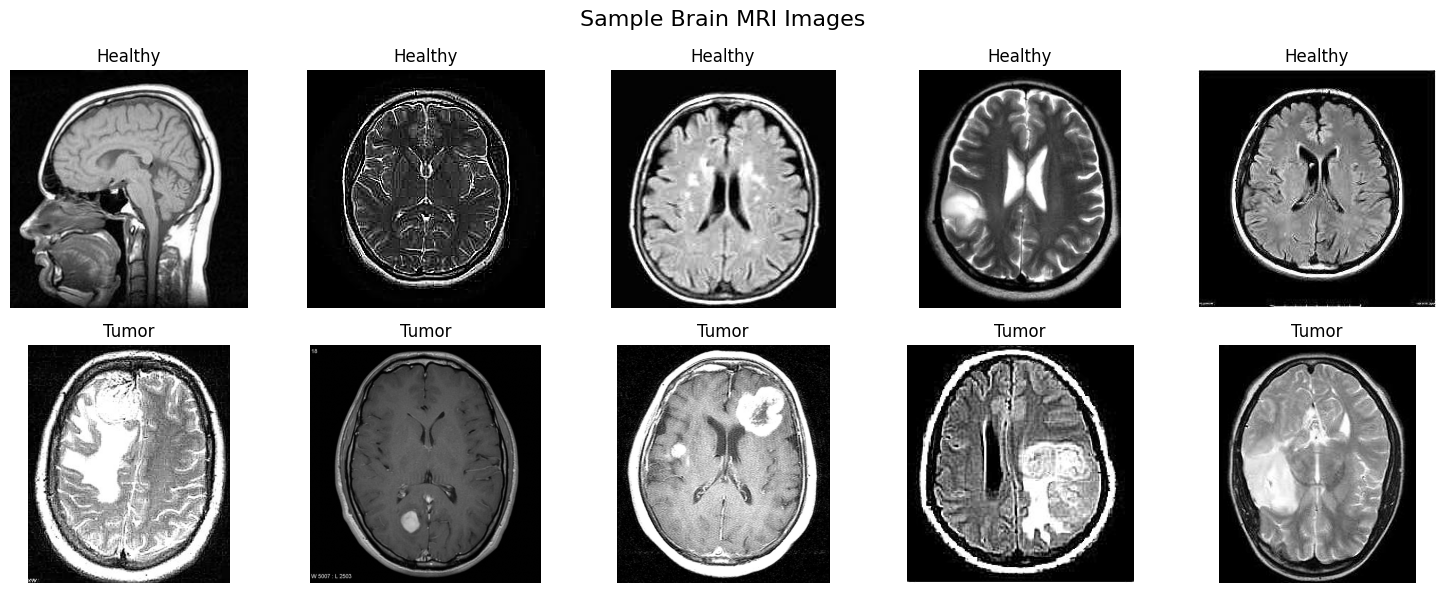

In [ ]:
#VISUALIZE
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Brain MRI Images', fontsize=16)

# Show 5 healthy images
for i in range(5):
    img = mpimg.imread(os.path.join(healthy_path, healthy_images[i]))
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title('Healthy')
    axes[0, i].axis('off')

# Show 5 tumor images
for i in range(5):
    img = mpimg.imread(os.path.join(tumor_path, tumor_images[i]))
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title('Tumor')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#PREPROCESSING
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = (224, 224)  # resize all images to this fixed size

images = []
labels = []

# Load healthy images
for img_name in healthy_images:
    img_path = os.path.join(healthy_path, img_name)
    try:
        img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')  # resize + force RGB
        img = img_to_array(img)   # convert to numpy array
        img = img / 255.0         # normalize 0-255 → 0-1
        images.append(img)
        labels.append(0)          # 0 = healthy
    except:
        pass                      # skip any corrupted files

# Load tumor images
for img_name in tumor_images:
    img_path = os.path.join(tumor_path, img_name)
    try:
        img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')
        img = img_to_array(img)
        img = img / 255.0
        images.append(img)
        labels.append(1)          # 1 = tumor
    except:
        pass

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)# number, size , color format
print("Labels shape:", labels.shape)

Images shape: (4600, 224, 224, 3)
Labels shape: (4600,)


In [ ]:
import numpy as np # to save 2 folders to drive so no re running cells

save_path = '/content/drive/MyDrive/Brain Tumor DataSet/'

np.save(save_path + 'images.npy', images)
np.save(save_path + 'labels.npy', labels)

print("Arrays saved to Drive!")

Arrays saved to Drive!


In [ ]:
from sklearn.model_selection import train_test_split

# Step 1 — Split into 70% train and 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels,
    test_size=0.30,        # 30% goes to temp
    random_state=42,       # makes split reproducible
    stratify=labels        # keeps class balance in each split
)

# Step 2 — Split the 30% temp into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,        # 50% of 30% = 15%
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 3220
Validation images: 690
Testing images: 690


In [ ]:
#MODEL BUILDING
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Fully Connected
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # 1 output — tumor or healthy
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,825 (84.86 MB)

 Trainable params: 22,245,377 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
#now we will compile the model
model.compile(
    optimizer='adam',                 # how model updates itself
    loss='binary_crossentropy',       # how model measures its mistake
    metrics=['accuracy']              # what we want to track
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks — these monitor training and help automatically
early_stop = EarlyStopping(
    monitor='val_loss',    # watches validation loss
    patience=5,            # stops if no improvement for 5 epochs
    restore_best_weights=True  # keeps the best version of model
)

checkpoint = ModelCheckpoint(
    'best_model.keras',        # saves best model to this file
    monitor='val_accuracy',
    save_best_only=True        # only saves when accuracy improves
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,                 # maximum 20 rounds of training
    batch_size=32,             # learns from 32 images at a time
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 30s 188ms/step - accuracy: 0.7034 - loss: 4.7448 - val_accuracy: 0.5464 - val_loss: 7.1517
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step - accuracy: 0.7745 - loss: 0.4936 - val_accuracy: 0.5899 - val_loss: 2.2179
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.8339 - loss: 0.3707 - val_accuracy: 0.6942 - val_loss: 1.4856
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 23s 225ms/step - accuracy: 0.8612 - loss: 0.3360 - val_accuracy: 0.8217 - val_loss: 0.6711
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 267ms/step - accuracy: 0.8630 - loss: 0.4251 - val_accuracy: 0.8304 - val_loss: 0.4121
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 37s 366ms/step - accuracy: 0.8835 - loss: 0.2683 - val_accuracy: 0.8855 - val_loss: 0.4187
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 475ms/step - accuracy: 0.8953 - loss: 0.2340 - val_accuracy: 0.9101 - val_loss: 0.2235
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 50s 494ms/step - accuracy: 0.9137 - loss: 0

```

**What each thing means:**

- **Epochs** — one epoch = model has seen all 3220 training images once. We do 20 rounds max
- **Batch size** — instead of learning from all images at once, it learns 32 at a time. More stable
- **EarlyStopping** — if model stops improving for 5 epochs it stops automatically, no wasted time
- **ModelCheckpoint** — automatically saves the best version of your model during training

In [ ]:
import shutil #to save our best model to drive not to rerun cells

shutil.copy(
    '/content/best_model.keras',
    '/content/drive/MyDrive/Brain Tumor DataSet/best_model.keras'
)

print("Model saved to Drive!")

Model saved to Drive!


 now that we have saved files to drive and the model also we dont
have to re run all cells everytime we lose our VM that is afer 90 minutes of inactivity
now we only have to run 3 cells

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# import numpy as np
# from sklearn.model_selection import train_test_split

# save_path = '/content/drive/MyDrive/Brain Tumor DataSet/'

# images = np.load(save_path + 'images.npy')
# labels = np.load(save_path + 'labels.npy')

# # Recreate splits
# X_train, X_temp, y_train, y_temp = train_test_split(
#     images, labels,
#     test_size=0.30,
#     random_state=42,
#     stratify=labels
# )
# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp,
#     test_size=0.50,
#     random_state=42,
#     stratify=y_temp
# )

# print("Data loaded!", images.shape)

In [ ]:
# from tensorflow.keras.models import load_model

# model = load_model(save_path + 'best_model.keras')
# print("Model loaded and ready!")

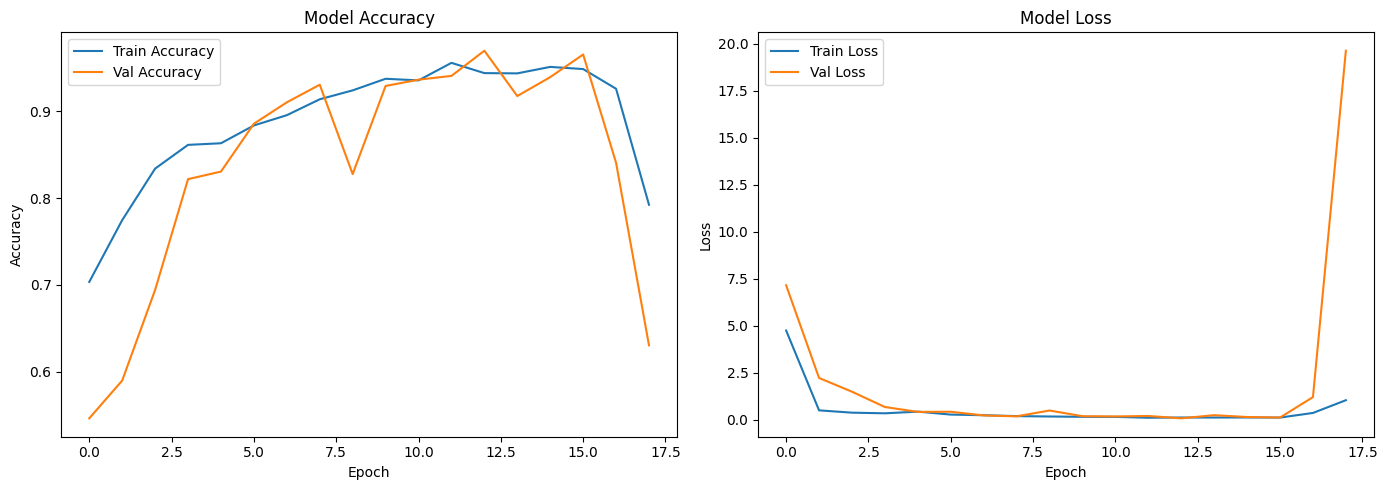

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Step 1 — Basic test accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 95.80%
Test Loss: 0.1691


22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step


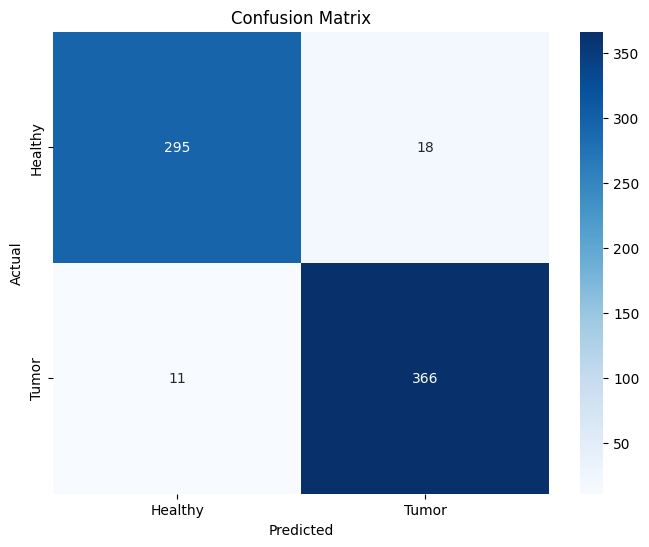

              precision    recall  f1-score   support

     Healthy       0.96      0.94      0.95       313
       Tumor       0.95      0.97      0.96       377

    accuracy                           0.96       690
   macro avg       0.96      0.96      0.96       690
weighted avg       0.96      0.96      0.96       690



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Get predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Tumor'],
            yticklabels=['Healthy', 'Tumor'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Detailed report
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Tumor']))

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

def predict_tumor(image_path):
    # Load and preprocess the image
    img = load_img(image_path, target_size=(224, 224), color_mode='rgb')
    img_array = img_to_array(img) / 255.0          # normalize
    img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

    # Predict
    prediction = model.predict(img_array)[0][0]

    # Show result
    plt.imshow(load_img(image_path))
    plt.axis('off')

    if prediction > 0.5:
        plt.title(f"Prediction: TUMOR 🔴 ({prediction*100:.2f}% confidence)", fontsize=14)
    else:
        plt.title(f"Prediction: HEALTHY 🟢 ({(1-prediction)*100:.2f}% confidence)", fontsize=14)

    plt.show()
    print(f"Raw prediction score: {prediction:.4f}")
    print("(Score closer to 1 = Tumor, closer to 0 = Healthy)")

In [ ]:
# Check actual filenames in both folders
healthy_files = os.listdir('/content/dataset/Brain Tumor Data Set/Healthy')
tumor_files = os.listdir('/content/dataset/Brain Tumor Data Set/Brain Tumor')

print("First 5 Healthy files:", healthy_files[:5])
print("First 5 Tumor files:", tumor_files[:5])

First 5 Healthy files: ['Not Cancer  (376).jpg', 'Not Cancer  (665).jpg', 'Not Cancer  (1176).jpg', 'Not Cancer  (1498).jpg', 'Not Cancer  (1676).jpg']
First 5 Tumor files: ['Cancer (1406).jpg', 'Cancer (979).jpg', 'Cancer (1523).jpg', 'Cancer (1524).jpg', 'Cancer (1653).jpg']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


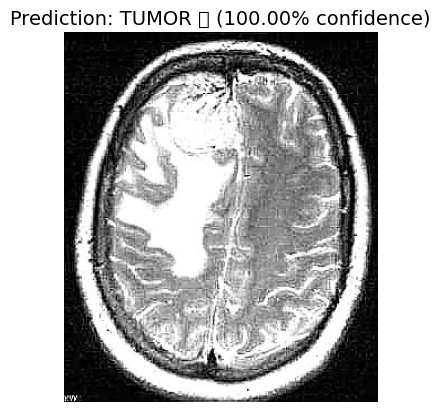

Raw prediction score: 1.0000
(Score closer to 1 = Tumor, closer to 0 = Healthy)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


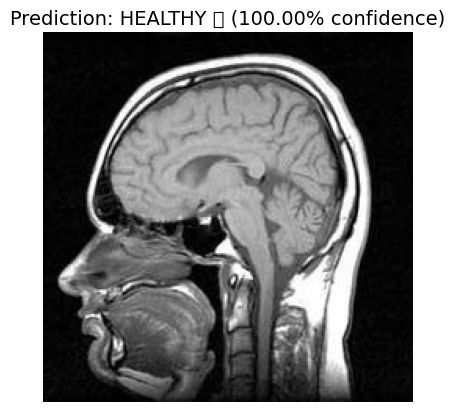

Raw prediction score: 0.0000
(Score closer to 1 = Tumor, closer to 0 = Healthy)


In [ ]:
# Test with a tumor image
predict_tumor('/content/dataset/Brain Tumor Data Set/Brain Tumor/Cancer (1406).jpg')

# Test with a healthy image
predict_tumor('/content/dataset/Brain Tumor Data Set/Healthy/Not Cancer  (376).jpg')